# Apresentação

Este é um projeto da disciplina Operacionalização de Modelos com MLOps do Instituto INFNET. Este notebook e os dataset necessários para esse projeto estão disponíveis no repositório: https://github.com/victorlima090/fundamentos-ml-ops.

# Projeto de Disciplina Operacionalização de Modelos com MLOps


# Contexto
No contexto do nosso problema, temos uma empresa que produz e comercializa safras de vinho vermelho e branco. Esta empresa gostaria de, antes de mandar uma safra para que receba uma nota de avaliação, realizar uma predição sobre a qualidade do vinho, para que possa decidir enviar somente os vinhos que sabe que terão notas altas, e assim, aumentar a reputação da empresa.

Dessa forma, o dataset a ser analisado consiste de informações químicas de várias vinhos que passaram pela avaliação de especialistas. O resultado final, será uma página, onde é possível imputar as qualidades químicas de um vinho que quer analisar, e receber a probabilidade do mesmo receber uma nota alta, acima de 7, e ser classificado como um vinho recomendado para avaliação humana.

Existem diversas escalas de classificação de vinho utilizadas no mercado, e como o dataset possui uma feature score que vai de 0 a 10, foi escolhido utilizar a escala de Robert Parker, mesma escala utilizada pelo site Wine Spectator, que contem centenas de milhares de avaliações de vinho.
Nessa escala, a nota vai de 0 a 100, e segue as seguintes faixas:
- 96–100 – Extraordinário
- 90–95 – Excepcional
- 80–89 – Pouco acima da média até muito bom
- 70–79 – Médio
- 60–69 – Abaixo da média
- 50–59 – Inaceitável

Dessa forma, para se adaptar ao dataset, a escala foi reduzida para:
- 9,6–10 – Extraordinário
- 9,0–9,5 – Excepcional
- 8,0–8,9 – Pouco acima da média até muito bom
- 7,0–7,9 – Médio
- 6,0–6,9 – Abaixo da média
- 5,0–5,9 – Inaceitável

Foi escolhido como 7 a nota de corte para determinar se um vinho é recomendado ou não.

Neste trabalho, foi decidido que a métrica principal a ser otimizada no modelo é a precisão, uma vez que, é preferível evitar ao máximo que vinhos de baixa qualidade sejam mandados para a avaliação. Além disso, pelo dataset ser desbalanceado, onde a maioria de vinhos de qualidade abaixo de 7, a precisão se torna uma métrica melhor do que a acurácia.

# Objetivo
O objetivo desse trabalho é criar um projeto de Machine Learning operacional, que contenha as principais etapas do ciclo de vida de um modelo, e que seja facilmente reproduzível através de uma estrutura robusta de pipelines. 

Neste projeto, temos a ingestão de dados, através da API do kaggle, o pré processamento dos mesmo e, por fim, a modelagem. Além disso, foi criada duas páginas web através da ferramenta StreamLit, onde é possível testar o melhor modelo treinado, além de monitorar se o modelo está defasado ou não.


# Fonte de dados
A fonte de dados utilizada é de um trabalho https://www.researchgate.net/publication/221612614_Using_Data_Mining_for_Wine_Quality_Assessment, que coletou amostras do vinho Vinho Verde, produzido na região de Minho, em Portugal. O dataset desse trabalho foi disponibilizado no seguinte link: https://www.kaggle.com/datasets/alirezamehrad/red-and-white-wine-quality. 

## Dataset
O dataset é composto por característica químicas dos vinhos e uma nota de qualidade sobre ele. Ao fazer uma análise exploratória dos dados, verificou-se que diversas colunas possuíam um skewness alto, conforme o gráfico abaixo:

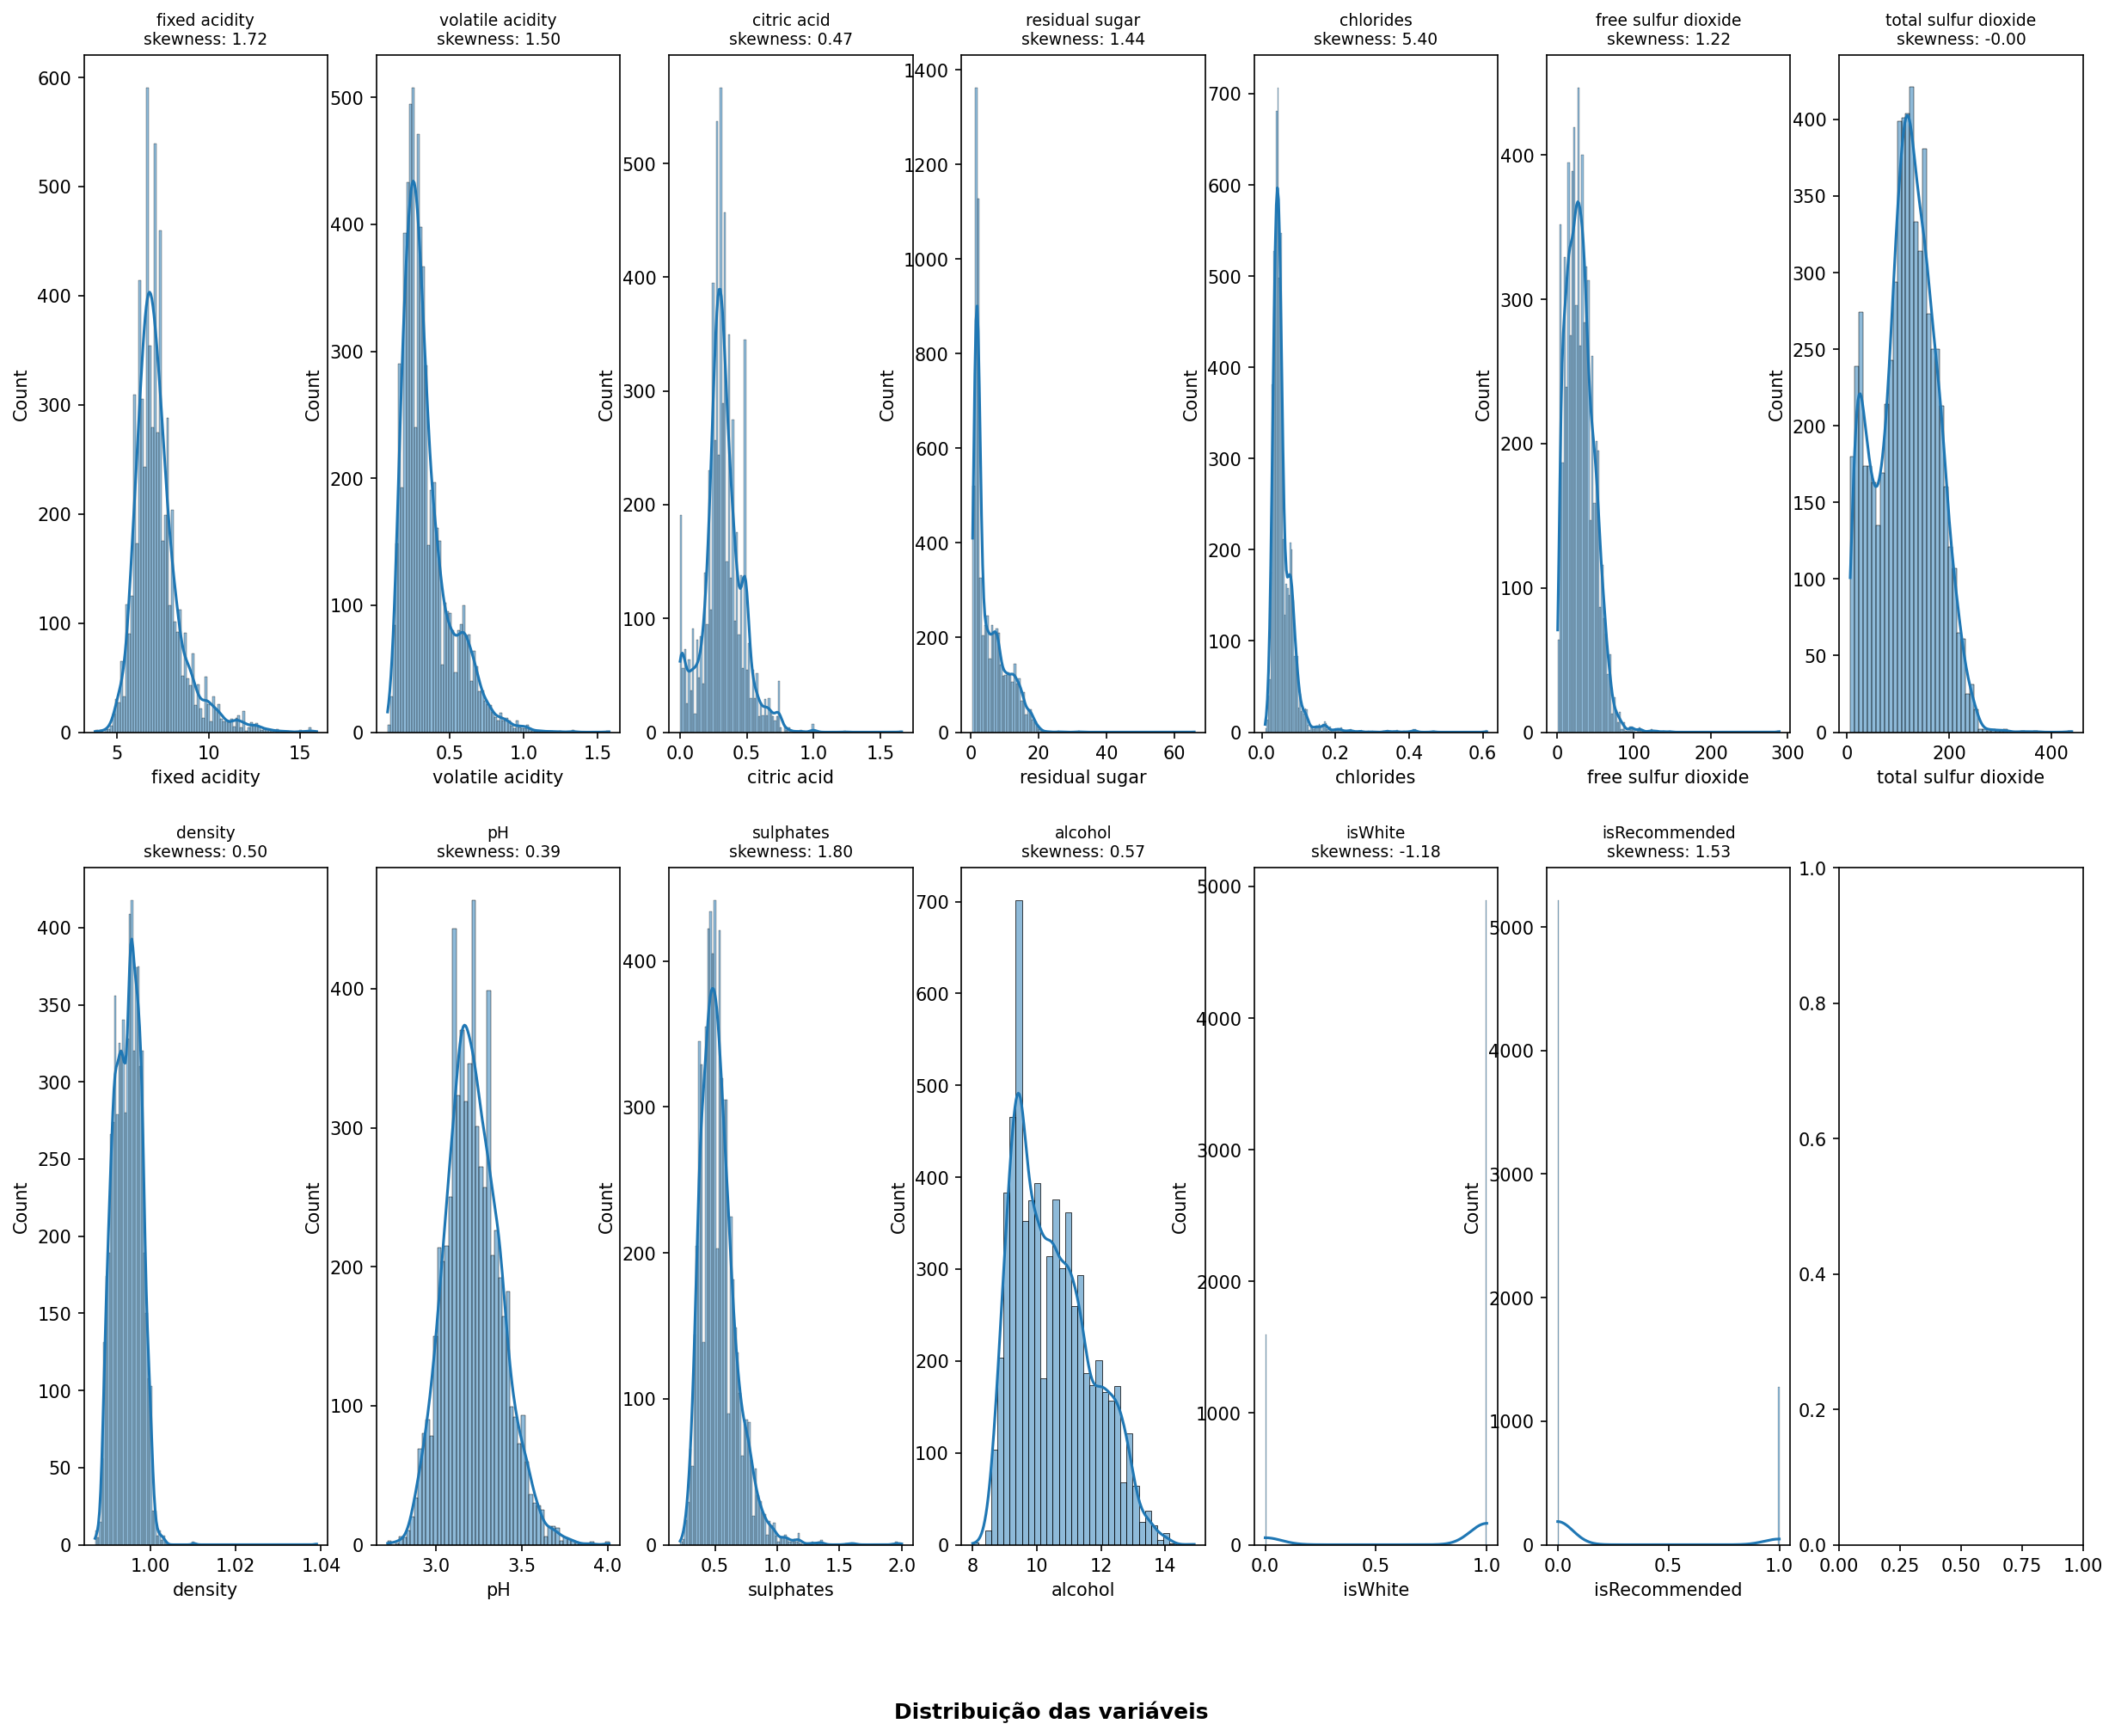

Além disso, verificou-se que o dataset possui um desbalanceamento de classes, onde há uma maioria de amostras de vinhos não recomendados, conforme o gráfico abaixo:

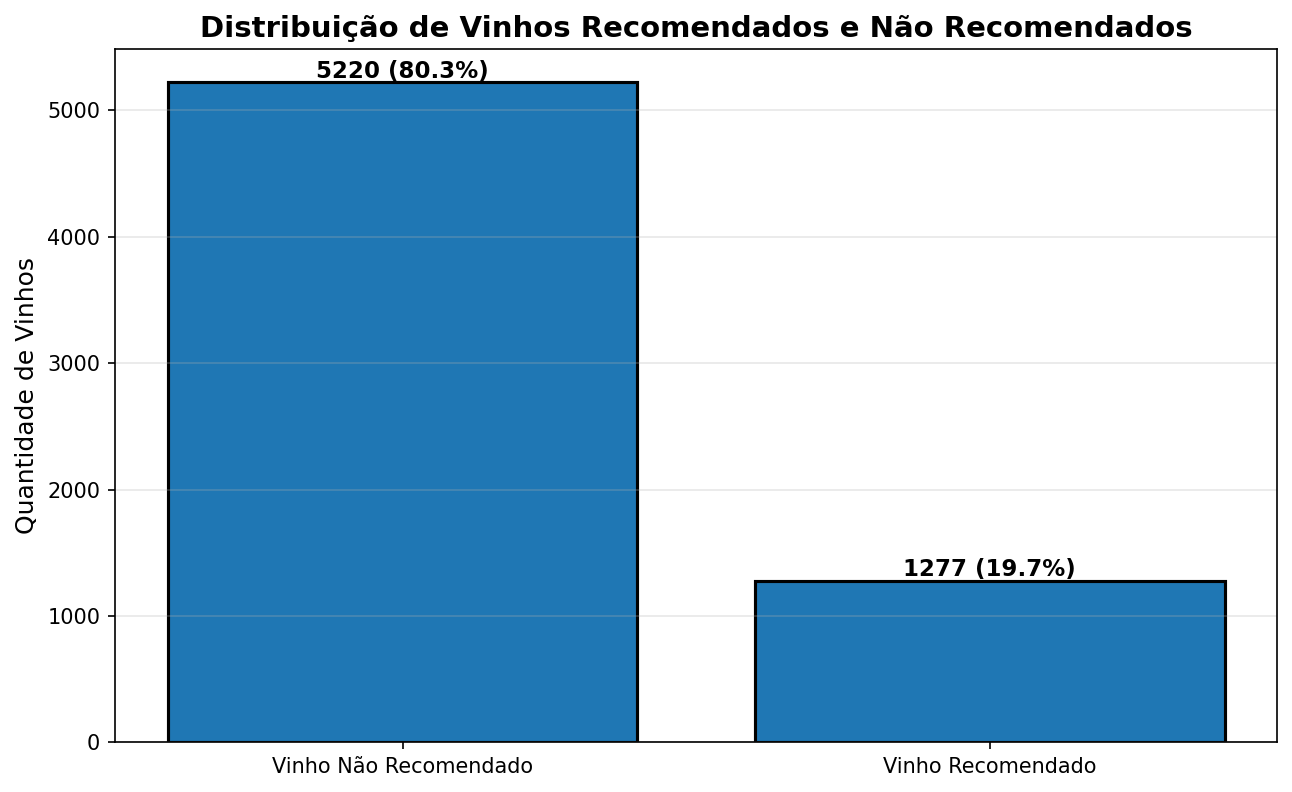

Por fim, observa-se que o dataset não possui valores nulos ou zeros.

# Arquitetura
Este projeto foi separado em três etapas: ingestão, pré processamento e modelagem.


## Ingestão
Esta é a etapa responsável pelo download do dataset e seu armazenamento. Nesta etapa, verifica-se a disponibilidade da fonte de dados, que neste projeto vim pela url https://www.kaggle.com/datasets/alirezamehrad/red-and-white-wine-quality, além de verificar se há uma correspondência entre os arquivos baixados e os arquivos que eram esperados. 

Nesta etapa, também é possível configurar para que o download não seja feito caso o dataset já esteja presente.



## Pré Processamento
Esta etapa prepara o dataset para a modelagem, realizando diversas transformações. Essas transformações se mostraram necessárias durante uma análise exploratória prévia do dataset. Segue abaixo as transformações realizadas:


### Transformação de Features Categoricas Binárias
Este dataset possui uma feature categórica chamada Type, com os valores "red" e "white", para distinguir os tipos de vinho. Essa feature foi transformada numa feature binária chamada "isWhite" para o treinamento posterior do modelo.


### Transformação Logarítmica
 A transformação logarítmica decorre de algumas features possuírem uma skewness maior que 1.5, logo, possuem uma cauda longa que distorce modelos lineares e aumenta a influência de outliers.
### Razões de Features
Foi verificado que algumas features, quando combinadas entre si, trazem maior correlação com a variável target, se forem unidas através de uma razão, como "ph/alcohol". Dessa forma, novas features baseadas nas originais foram criadas para o dataset.

### Seleção de Features
Nesta etapa final, retira-se algumas das colunas originais, pois o dataset cresceu em dimensionalidade, o que aumenta o custo operacional.

## Modelagem

Nesta etapa, o dataset já preparado, será separado nos conjuntos de treino e teste para que não haja vazamento de dados. Em seguida, de acordo com o arquivo de configuração, será realizado um teste com diversos modelos diferentes, em que será feita uma otimização dos seus parâmetros com a ferramenta Optuna. Os dados dos treinamentos desses modelos serão armazenados num servidor do MlFlow, onde o melhor modelo, através da métrica escolhida, será armazenado para que possa ser utilizada em um ambiente produtivo.

### Modelos
Os modelos escolhidos para serem testados nessa etapa foram:
- Regressão Logística
- Árvore de decisão
- Knn
- Random Forest
- Gradiente Boosting
- XGBoost
- LightGBM
  
A regressão logística, pela sua simplicidade, foi considerada como um modelo baseline, que serve de comparação com os outros modelos que são mais complexos e de maior custo computacional.


## Técnicas de Redução de Dimensionalidade
Além da otimização de parâmetros dos modelos, foi testado o impacto da aplicação de técnicas de redução de dimensionalidade como: PCA, RFE, KPCA.

## Modelo Final Escolhido

O modelo final escolhido foi aquele com a maior precisão média, uma vez que, pelo contexto do negócio onde a empresa quer evitar ao máximo os falsos positivos, a precisão se torna a métrica mais importante a ser analisada.

# Streamlit e Mlflow
Segue abaixo um vídeo demonstrando o uso do modelo escolhido em um ambiente produtivo, e o mlflow.